<a href="https://colab.research.google.com/github/zer0punch/zer0punch/blob/practice_1/%D0%9F%D1%80%D0%B0%D0%BA%D1%82%D0%B8%D1%87%D0%B5%D1%81%D0%BA%D0%B0%D1%8F_%D1%80%D0%B0%D0%B1%D0%BE%D1%82%D0%B0_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Задача 1. Обнаружение фальшивых новостей

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import PassiveAggressiveClassifier
from sklearn.metrics import classification_report, accuracy_score

df = pd.read_csv("fake_news.csv")
texts = df["text"].astype(str)
labels = df["label"]

X_train_texts, X_test_texts, y_train, y_test = train_test_split(
    texts,
    labels,
    test_size=0.2,
    random_state=42,
    stratify=labels
)

vectorizer = TfidfVectorizer(
    max_df=0.9,
    min_df=5
)

X_train = vectorizer.fit_transform(X_train_texts)
X_test = vectorizer.transform(X_test_texts)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

clf = PassiveAggressiveClassifier(
    C=1.0,
    max_iter=1000,
    loss="hinge"
)

clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))


Train shape: (5068, 21694)
Test shape: (1267, 21694)
Accuracy: 0.9463299131807419
              precision    recall  f1-score   support

        FAKE       0.94      0.95      0.95       633
        REAL       0.95      0.94      0.95       634

    accuracy                           0.95      1267
   macro avg       0.95      0.95      0.95      1267
weighted avg       0.95      0.95      0.95      1267



### Матрица ошибок

<Figure size 500x500 with 0 Axes>

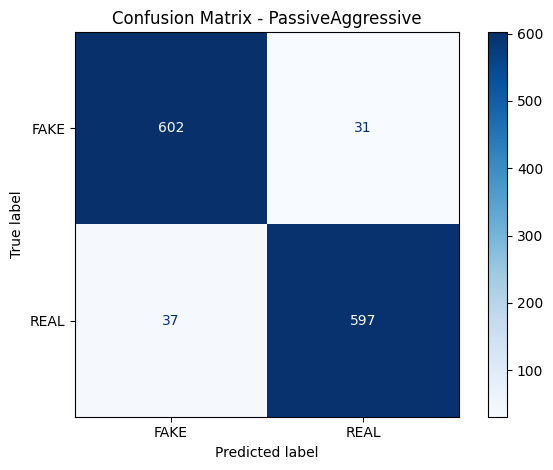

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred, labels=clf.classes_)

disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=clf.classes_)

plt.figure(figsize=(5, 5))
disp.plot(cmap="Blues", values_format="d")
plt.title("Confusion Matrix - PassiveAggressive")
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.tight_layout()
plt.show()


Наиболее критичной в данном кейсе является ошибка нераспознования фейка. Но процент таких ошибок невелик, ~4.9%. Большого дисбаланса по ошибкам не наблюдается.

### Визуализация самых важных признаков

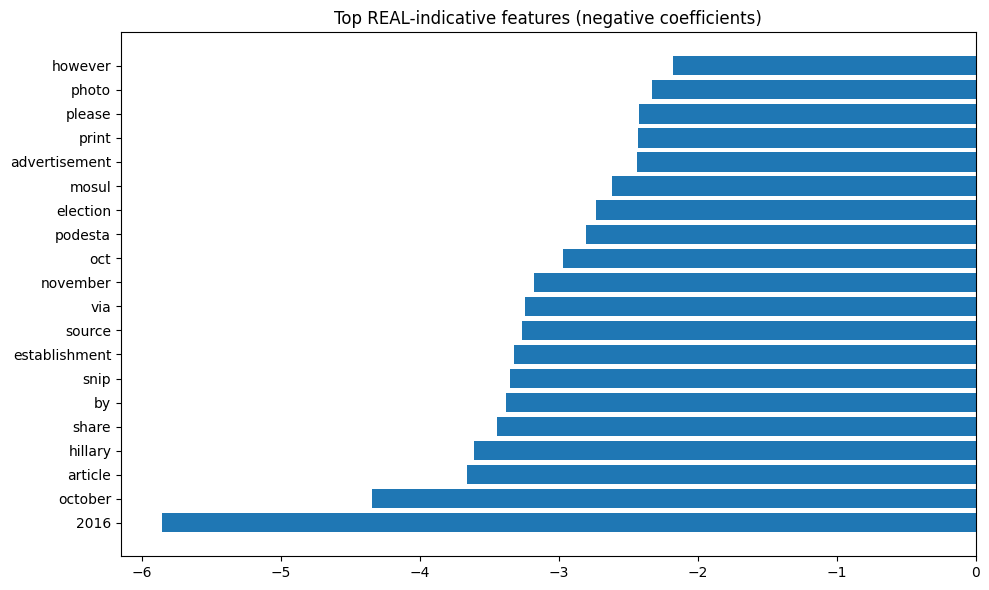

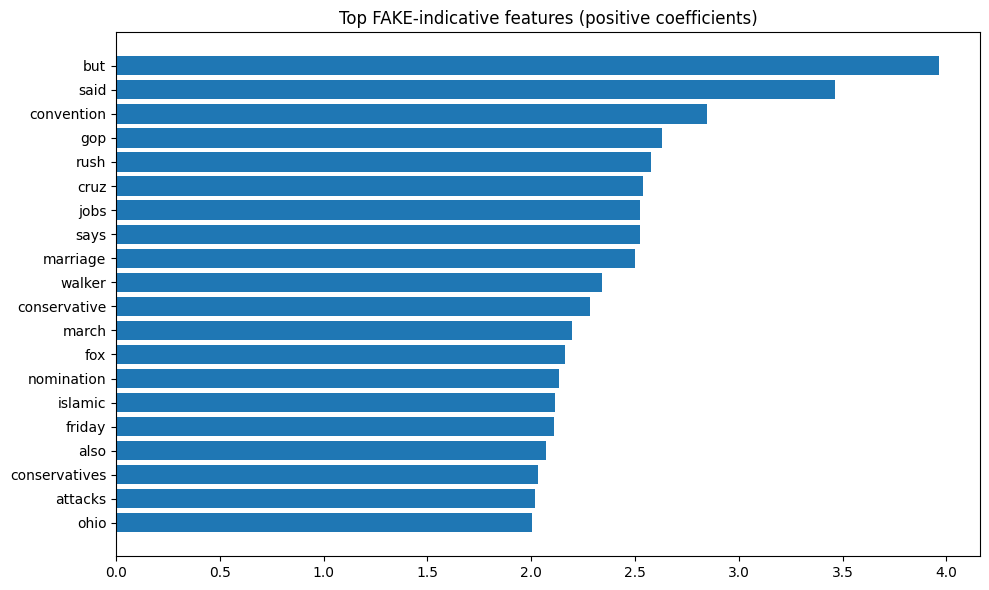

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

feature_names = vectorizer.get_feature_names_out()
coefs = clf.coef_[0]

def plot_top_features(coefs, feature_names, top_n=20):
    top_fake_idx = np.argsort(coefs)[-top_n:]
    top_real_idx = np.argsort(coefs)[:top_n]

    plt.figure(figsize=(10, 6))
    plt.barh(range(top_n), coefs[top_real_idx], align="center")
    plt.yticks(range(top_n), feature_names[top_real_idx])
    plt.title("Top REAL-indicative features (negative coefficients)")
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(10, 6))
    plt.barh(range(top_n), coefs[top_fake_idx], align="center")
    plt.yticks(range(top_n), feature_names[top_fake_idx])
    plt.title("Top FAKE-indicative features (positive coefficients)")
    plt.tight_layout()
    plt.show()

plot_top_features(coefs, feature_names, top_n=20)

Из графика, в целом, видно, что в фейковых новостях часто прибегают к использованию более эмоционально окрашенных слов. В то же время, в реальных новостях используется более формализованный язык, фактологический. Наиболее примечательно, что для фейковых новостей самым популярным маркером является "but". На первый взгляд просто союз, связующая конструкция. Но многие фейковые новости характерны построением контрастов. Условно: "официальные источники утверждают следующее: ..., но на самом деле ...". Серьезные издания предпочитают язык фактов, а не противопоставлений.

### Задача 2. Обнаружение болезни паркинсона с помощью XGBoost

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score
from xgboost import XGBClassifier

data = pd.read_csv("parkinsons.data")
print(data.head())
print(data.columns)

X = data.drop(columns=["name", "status"])
y = data["status"]


             name  MDVP:Fo(Hz)  MDVP:Fhi(Hz)  MDVP:Flo(Hz)  MDVP:Jitter(%)  \
0  phon_R01_S01_1      119.992       157.302        74.997         0.00784   
1  phon_R01_S01_2      122.400       148.650       113.819         0.00968   
2  phon_R01_S01_3      116.682       131.111       111.555         0.01050   
3  phon_R01_S01_4      116.676       137.871       111.366         0.00997   
4  phon_R01_S01_5      116.014       141.781       110.655         0.01284   

   MDVP:Jitter(Abs)  MDVP:RAP  MDVP:PPQ  Jitter:DDP  MDVP:Shimmer  ...  \
0           0.00007   0.00370   0.00554     0.01109       0.04374  ...   
1           0.00008   0.00465   0.00696     0.01394       0.06134  ...   
2           0.00009   0.00544   0.00781     0.01633       0.05233  ...   
3           0.00009   0.00502   0.00698     0.01505       0.05492  ...   
4           0.00011   0.00655   0.00908     0.01966       0.06425  ...   

   Shimmer:DDA      NHR     HNR  status      RPDE       DFA   spread1  \
0      0.0654

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y  # чтобы класс-баланс сохранился
)


### Обучение классификатора

In [ ]:
model = XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="logloss",
    tree_method="hist",
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=4, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=-1,
              num_parallel_tree=None, ...)

### Проверка качества

In [ ]:
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_proba))


              precision    recall  f1-score   support

           0       0.89      0.80      0.84        10
           1       0.93      0.97      0.95        29

    accuracy                           0.92        39
   macro avg       0.91      0.88      0.90        39
weighted avg       0.92      0.92      0.92        39

ROC-AUC: 0.9896551724137931


### Важность признаков

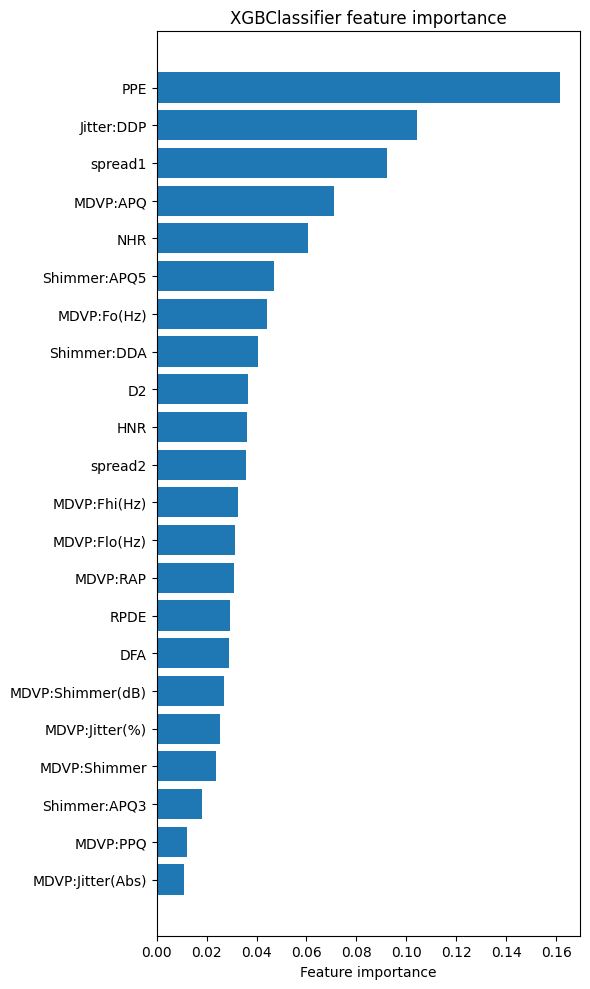

In [ ]:
import matplotlib.pyplot as plt

importances = model.feature_importances_
feat_names = X.columns

sorted_idx = importances.argsort()

plt.figure(figsize=(6, 10))
plt.barh(feat_names[sorted_idx], importances[sorted_idx])
plt.xlabel("Feature importance")
plt.title("XGBClassifier feature importance")
plt.tight_layout()
plt.show()






*   PPE (Pitch Period Entropy) — самый сильный предиктор.
Это показатель нестабильности вибрации голоса. У пациентов с болезнью Паркинсона вибрация становится менее регулярной.
*   Jitter и Shimmer измеряют микровариации частоты и амплитуды голоса. Это ключевые биомаркеры, потому что у больных чаще наблюдаются тремор и нестабильность голосовых связок.
*   NHR (Noise-to-Harmonics Ratio) — уровень шума в голосе. Увеличение шума — признак слабости голосовых связок.

В целом, XGBoost ориентируется на признаки, типичные для классической диагностики Паркинсона.





### SHAP summary

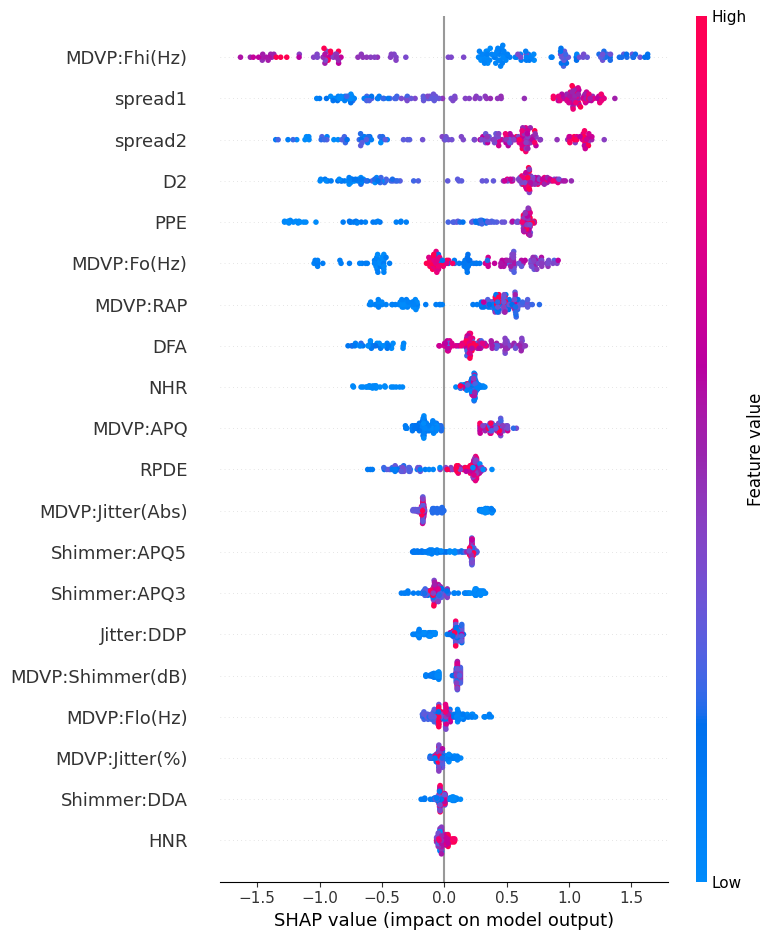

In [ ]:
import shap

explainer = shap.TreeExplainer(model)
shap_values = explainer(X_train)

shap.summary_plot(shap_values, X_train)

Результат отличается от простого анализа важности признаков, поскольку SHAP рассматривает реальное влияение на предсказание. Итак:
1. MDVP:Fhi(Hz) (максимальная частота).
  Высокие значения (красный) часто тянут предсказание в сторону болезни → SHAP > 0. Низкие значения (синий) чаще тянут в сторону здоровья. Это означает, что у пациентов с Паркинсоном максимальная частота голоса становится нестабильной и скачкообразной.
2. spread1 и spread2. Высокие значения (красный)устойчиво ведут к положительному классу (болезнь). Низкие значения — к здоровью.
3. PPE. SHAP показывает, что PPE действительно даёт большой вклад, но только для части наблюдений, где значения очень высокие.
4. NHR, Shimmer. Их вклад оказался не таким сильным или же они сильно коррелируют друг с другом.

## Задача 3. Тональность текстов

Для данной задачи было решено использовать датасет, включающий в себя 6 других, содержащих тексты:
 *  новостей на русском
 *  комментариев/сообщений с сайтов вроде 2ch.hk и pikabu.ru
 *  обзоров автомобилей
 *  различные другие «отзывные» тексты / рецензии из наборов «sentiment datasets by Blinov» и «LINIS Crowd»;

URL: https://huggingface.co/datasets/MonoHime/ru_sentiment_dataset

Классы:
*   0: NEUTRAL
*   1: POSITIVE
*   2: NEGATIVE

P.S. Блоки с разными параметрами моделей и предобработки сделаны независимыми друг от друга, чтоб можно было воспроизвести их только с блоком импортов и чтением датасета.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


### Импорты

In [ ]:
import csv
import sys
import re

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report, accuracy_score

from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.pipeline import FeatureUnion

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import ComplementNB
from sklearn.ensemble import StackingClassifier

import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import seaborn as sns

### Чтение датасета

In [ ]:
path = "/content/drive/MyDrive/datasets.csv"

# 1. Увеличиваем лимит размера поля
csv.field_size_limit(sys.maxsize)

# 2. Читаем CSV
df = pd.read_csv(
    path,
    engine="python",      # более терпимый парсер
    encoding="latin1",    # так безопасно читаем «битый» UTF-8
    on_bad_lines="skip"   # пропускаем повреждённые строки
)

# Сейчас у нас три колонки: Unnamed: 0, text, sentiment
# text пока в виде кракозябр типа "Ð Ð°Ð·Ð²Ð¾Ð´Ð° ..."

# 3. Чиним кодировку текста
df["text"] = df["text"].astype(str).apply(
    lambda x: x.encode("latin1", errors="ignore").decode("utf-8", errors="ignore")
)

# 4. Оставляем только тексты и разметку
df = df[["text", "sentiment"]]
df["sentiment"] = df["sentiment"].astype(int)

# Проверка
print(df.shape)
print(df.head())


(210989, 2)
                                                text  sentiment
0  Развода на деньги нет\nНаблюдаюсь в Лайфклиник...          1
1  Отель выбрали потому что рядом со стадионом. О...          0
2  Вылечили\nГноился с рождения глазик, в поликли...          1
3  Хорошее расположение.С вокзала дошли пешком.Но...          0
4  Отличное месторасположение,прекрасный вид,особ...          1


### Классификация с помощью SVM

### *Базовая модель без доработок*

In [ ]:
X = df["text"]
y = df["sentiment"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

vectorizer_base = TfidfVectorizer(
    max_features=100_000,
    ngram_range=(1, 2),
    min_df=2
)

X_train_tfidf_base = vectorizer_base.fit_transform(X_train)
X_test_tfidf_base = vectorizer_base.transform(X_test)

model_base = LinearSVC()  # C по умолчанию = 1.0
model_base.fit(X_train_tfidf_base, y_train)

y_pred_base = model_base.predict(X_test_tfidf_base)

print("=== Базовая модель LinearSVC ===")
print("Accuracy:", accuracy_score(y_test, y_pred_base))
print(classification_report(y_test, y_pred_base))


=== Базовая модель LinearSVC ===
Accuracy: 0.7437094799836786
              precision    recall  f1-score   support

           0       0.62      0.62      0.62      5717
           1       0.78      0.80      0.79     10535
           2       0.80      0.76      0.78      5805

    accuracy                           0.74     22057
   macro avg       0.73      0.73      0.73     22057
weighted avg       0.74      0.74      0.74     22057



### *SVM + предобработка текста*

In [ ]:
def simple_preprocess(text: str) -> str:
    if not isinstance(text, str):
        return ""
    text = text.lower()
    text = text.replace("\n", " ")
    text = re.sub(r"[^a-zа-яё ]+", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

russian_stopwords = [
    "и","в","во","не","что","он","на","я","с","со","как","а","то","все","она","так",
    "его","но","да","ты","к","у","же","вы","за","бы","по","только","ее","мне","было",
    "вот","от","меня","еще","нет","о","из","ему","теперь","когда","даже","ну","ли",
    "если","уже","или","ни","быть","был","него","до","вас","нибудь","опять","уж",
    "вам","ведь","там","потом","себя","ничего","ей","может","они","тут","где","есть",
    "надо","ней","для","мы","тебя","их","чем","была","сам","чтоб","без","будто","чего",
    "раз","тоже","себе","под","кто","этот","того","потому","этого","какой","совсем",
    "ним","здесь","этом","один","почти","мой","тем","чтобы","нее","сейчас","были",
    "куда","зачем","всех","никогда","можно","при","наконец","два","об","другой",
    "хоть","после","над","больше","тот","через","эти","нас","про","всего","них",
    "какая","много","разве","три","эту","моя","впрочем","хорошо","свою","этой",
    "перед","иногда","лучше","чуть","том","нельзя","такой","им","более","всегда",
    "конечно"
]

X_prep = df["text"].apply(simple_preprocess)
y = df["sentiment"]

X_train_prep, X_test_prep, y_train_prep, y_test_prep = train_test_split(
    X_prep, y, test_size=0.2, random_state=42, stratify=y
)

vectorizer_prep = TfidfVectorizer(
    max_features=100_000,
    ngram_range=(1, 2),
    min_df=2,
    stop_words=russian_stopwords
)

X_train_tfidf_prep = vectorizer_prep.fit_transform(X_train_prep)
X_test_tfidf_prep = vectorizer_prep.transform(X_test_prep)

model_prep = LinearSVC()
model_prep.fit(X_train_tfidf_prep, y_train_prep)

y_pred_prep = model_prep.predict(X_test_tfidf_prep)

print("=== Модель с предобработкой ===")
print("Accuracy:", accuracy_score(y_test_prep, y_pred_prep))
print(classification_report(y_test_prep, y_pred_prep))


=== Модель с предобработкой ===
Accuracy: 0.7380876819150383
              precision    recall  f1-score   support

           0       0.62      0.61      0.61      5717
           1       0.77      0.80      0.79     10535
           2       0.79      0.76      0.77      5805

    accuracy                           0.74     22057
   macro avg       0.73      0.72      0.72     22057
weighted avg       0.74      0.74      0.74     22057



### *SVM + предобработка + подбор C (регуляризация)*

In [ ]:
pipeline = Pipeline([
    ("vect", TfidfVectorizer(
        max_features=100_000,
        ngram_range=(1, 2),
        min_df=2,
        stop_words=russian_stopwords,
        preprocessor=simple_preprocess  # используем функцию предобработки из предыдущего блока
    )),
    ("clf", LinearSVC())
])

param_grid = {
    "clf__C": [0.1, 0.5, 1.0, 2.0, 5.0],
}

grid = GridSearchCV(
    pipeline,
    param_grid=param_grid,
    cv=3,
    n_jobs=-1,
    verbose=1,
    scoring="accuracy"
)

X = df["text"]
y = df["sentiment"]

grid.fit(X, y)

print("=== Лучшая модель (GridSearchCV) ===")
print("Лучшие параметры:", grid.best_params_)
print("Лучшая CV-точность:", grid.best_score_)

X_train_full, X_test_full, y_train_full, y_test_full = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

best_model = grid.best_estimator_
best_model.fit(X_train_full, y_train_full)
y_pred_best = best_model.predict(X_test_full)

print("Accuracy на тесте:", accuracy_score(y_test_full, y_pred_best))
print(classification_report(y_test_full, y_pred_best))


Fitting 3 folds for each of 5 candidates, totalling 15 fits
=== Лучшая модель (GridSearchCV) ===
Лучшие параметры: {'clf__C': 0.1}
Лучшая CV-точность: 0.7449108203440241
Accuracy на тесте: 0.7488779072403319
              precision    recall  f1-score   support

           0       0.64      0.62      0.63      5717
           1       0.77      0.82      0.80     10535
           2       0.81      0.74      0.78      5805

    accuracy                           0.75     22057
   macro avg       0.74      0.73      0.73     22057
weighted avg       0.75      0.75      0.75     22057



Как видно, предобработка текста не дала ощутимого прироста в качестве определения, даже слегка его ухудшила. Возможная причина в утрате нюансов с удалением некоторых стоп-слов и пунктуации. В дополнительной настройке параметров SVC очевидно тоже не нуждается и в основном зависит лишь от C.

Для потенциального улучшения можно попробовать объединить два подхода: использование n-грамм символов и n-грамм слов.

### *SVM + word TF-IDF & char TF-IDF*

In [ ]:
X = df["text"]
y = df["sentiment"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

word_vectorizer = TfidfVectorizer(
    analyzer="word",
    ngram_range=(1, 2),
    max_features=200_000,
    min_df=2
)

char_vectorizer = TfidfVectorizer(
    analyzer="char",
    ngram_range=(3, 6),
    max_features=200_000
)

features = FeatureUnion([
    ("word", word_vectorizer),
    ("char", char_vectorizer)
])

model = Pipeline([
    ("features", features),
    ("clf", LinearSVC(C=1.0))
])

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("=== Word TF-IDF + Char TF-IDF → LinearSVC ===")
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

=== Word TF-IDF + Char TF-IDF → LinearSVC ===
Accuracy: 0.770508066230484
              precision    recall  f1-score   support

           0       0.65      0.65      0.65     11014
           1       0.81      0.82      0.81     20224
           2       0.83      0.80      0.81     11099

    accuracy                           0.77     42337
   macro avg       0.76      0.76      0.76     42337
weighted avg       0.77      0.77      0.77     42337



Еще одна потенциальная возможность улучшить результат — объединение нескольких моделей в пайплайн.

In [ ]:
X = df["text"]
y = df["sentiment"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

word_vectorizer = TfidfVectorizer(
    analyzer="word",
    ngram_range=(1, 2),
    max_features=200_000,
    min_df=3,
    sublinear_tf=True
)

char_vectorizer = TfidfVectorizer(
    analyzer="char",
    ngram_range=(3, 5),
    max_features=50_000,
    min_df=5
)

features_word_char = FeatureUnion(
    transformer_list=[
        ("word", word_vectorizer),
        ("char", char_vectorizer),
    ],
    transformer_weights={
        "word": 1.0,
        "char": 0.3,
    }
)

estimators = [
    ("svm", LinearSVC(C=0.5, random_state=42)),
    ("logreg", LogisticRegression(
        max_iter=5000,
        n_jobs=-1,
        class_weight="balanced",
        random_state=42
    )),
    ("cnb", ComplementNB())
]

final_est = LogisticRegression(
    max_iter=5000,
    n_jobs=-1,
    class_weight="balanced",
    random_state=42
)

stacking_clf = StackingClassifier(
    estimators=estimators,
    final_estimator=final_est,
    cv=3,
    n_jobs=-1
)

model = Pipeline([
    ("features", features_word_char),
    ("clf", stacking_clf)
])

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("=== Word+Char TF-IDF + Stacking(SVM,LogReg,CNB) ===")
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))



=== Word+Char TF-IDF + Stacking(SVM,LogReg,CNB) ===
Accuracy: 0.7714583629555903
              precision    recall  f1-score   support

           0       0.62      0.78      0.69     10977
           1       0.88      0.73      0.80     20159
           2       0.80      0.84      0.82     11062

    accuracy                           0.77     42198
   macro avg       0.77      0.78      0.77     42198
weighted avg       0.79      0.77      0.77     42198



Отсюда видно, что основной вклад в качество даёт именно расширение признакового описания (word+char), а не усложнение классификатора. Далее на тех же признаках ансамбли уже не дают ощутимого улучшения. Для более подробного анализа остается проанализировать некоторые графики.

### *Матрица ошибок*

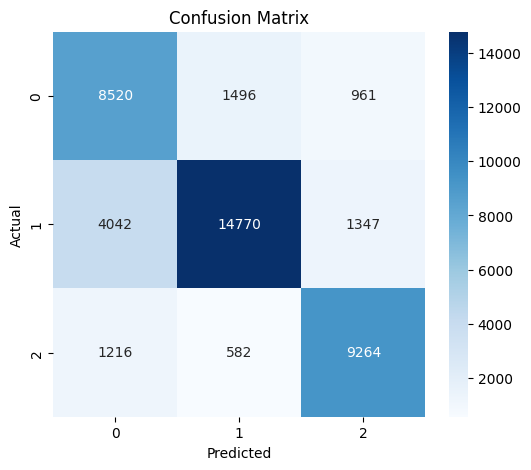

In [ ]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

Позитивные тексты в целом легко распознаваемы, но «слабо-позитивные» уходят в класс нейтральных. Грубых ошибок в виде путанницы между негативными и позитивными сообщениями почти не наблюдается. Нейтральные тексты часто содержат оценочные формулировки (слегка положительные/отрицательные), и модель «сдвигает» их к выраженным эмоциям.

### *Топ признаков (words/chars)*

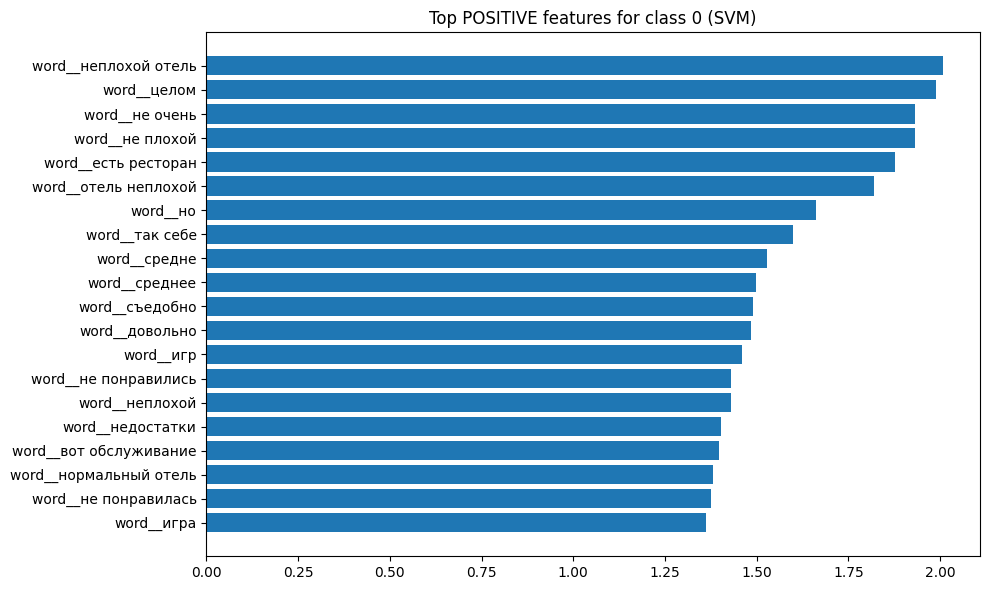

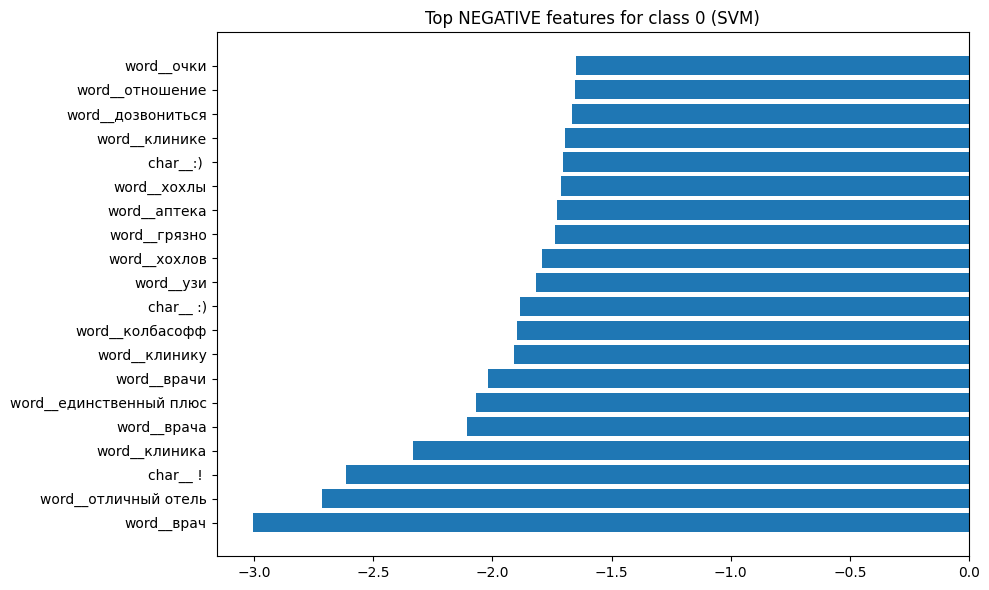

In [ ]:
features = model.named_steps["features"]

feature_names = []
for name, transformer in features.transformer_list:
    # вытаскиваем имена признаков только там, где это возможно
    if hasattr(transformer, "get_feature_names_out"):
        names = transformer.get_feature_names_out()
        feature_names.extend([f"{name}__{n}" for n in names])

stack_clf = model.named_steps["clf"]

svm_idx = [i for i, (name, _) in enumerate(stack_clf.estimators) if name == "svm"][0]
svm_clf = stack_clf.estimators_[svm_idx]

coefs = svm_clf.coef_

def plot_top_features(class_idx, topn=20):
    coef = coefs[class_idx]

    top_pos_idx = np.argsort(coef)[-topn:]
    top_neg_idx = np.argsort(coef)[:topn]

    plt.figure(figsize=(10, 6))
    plt.barh([feature_names[i] for i in top_pos_idx], coef[top_pos_idx])
    plt.title(f"Top POSITIVE features for class {class_idx} (SVM)")
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(10, 6))
    plt.barh([feature_names[i] for i in top_neg_idx], coef[top_neg_idx])
    plt.title(f"Top NEGATIVE features for class {class_idx} (SVM)")
    plt.tight_layout()
    plt.show()

plot_top_features(class_idx=0, topn=20)

Отсюда видно, что нейтральность характеризуется в большей степени не полным отсутсвием эмоциональности, а, скорее, слабой эмоциональностью. Например:
*  негативные частицы + нейтральные слова ("неплохой", "не очень") — выражают слабую эмоцию;
*  компромиссные оценки ("в целом", "средне", "так себе") — нет активной эмоциональности;
*  структурные слова ("но", "довольно", "съедобно") — это "смягчители" эмоционального тона, типичные для нейтральных отзывов.

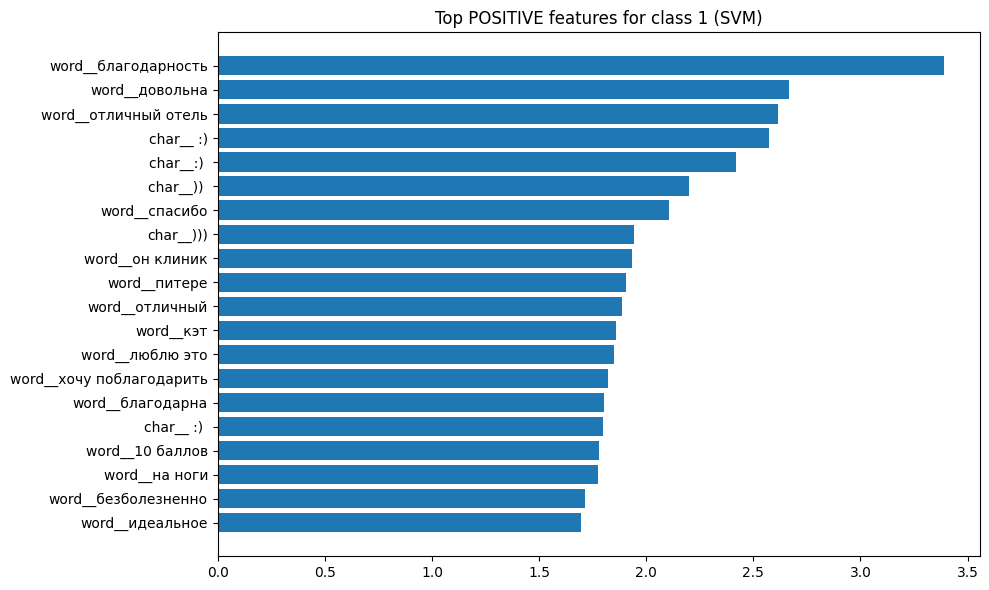

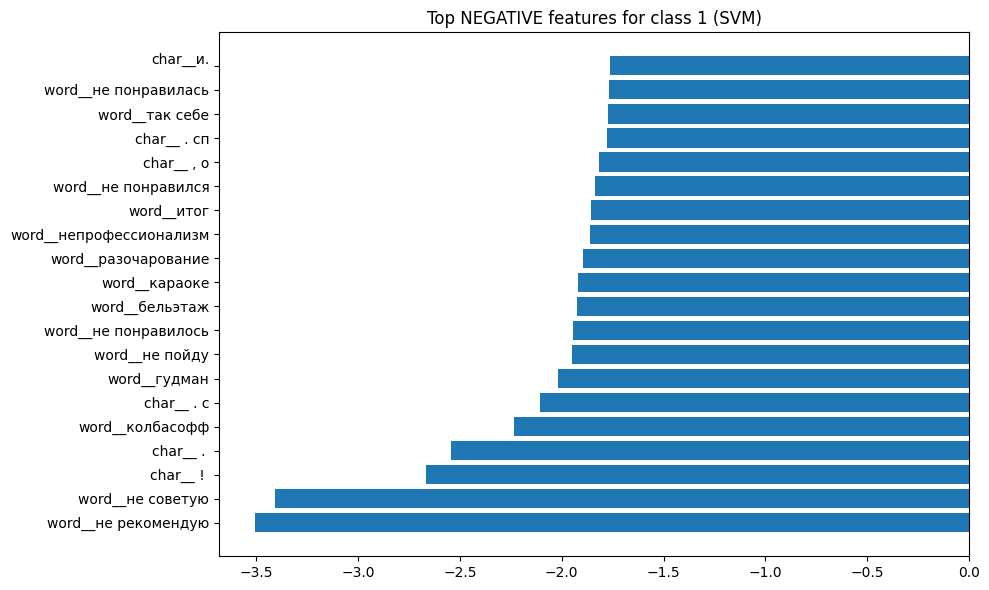

In [ ]:
plot_top_features(class_idx=1, topn=20)

Благодаря символьным n-граммам улавливаются не только маркеры благодарности и оценочные прилагательные, но и смайлики позитивных эмоций.

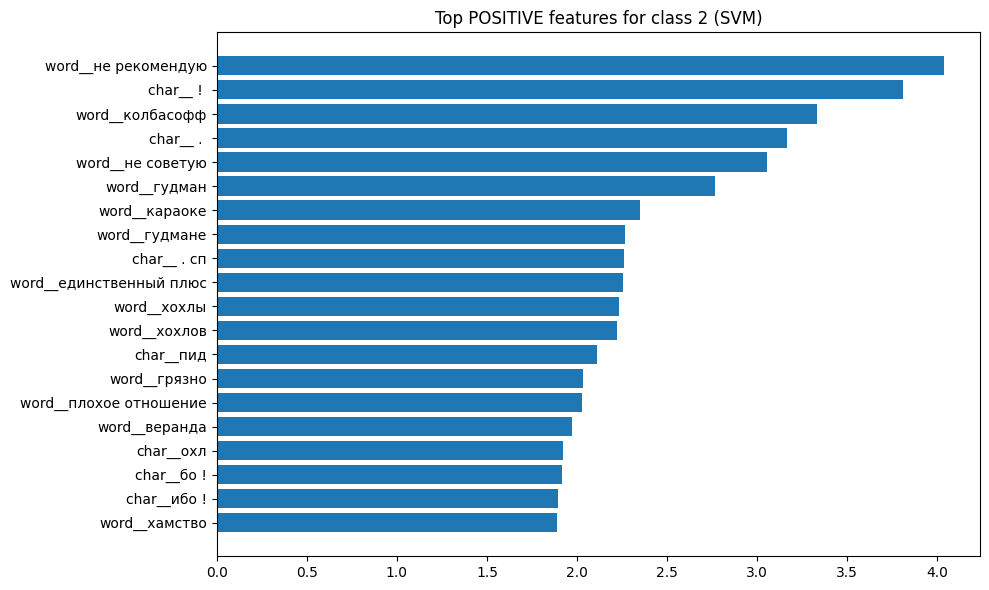

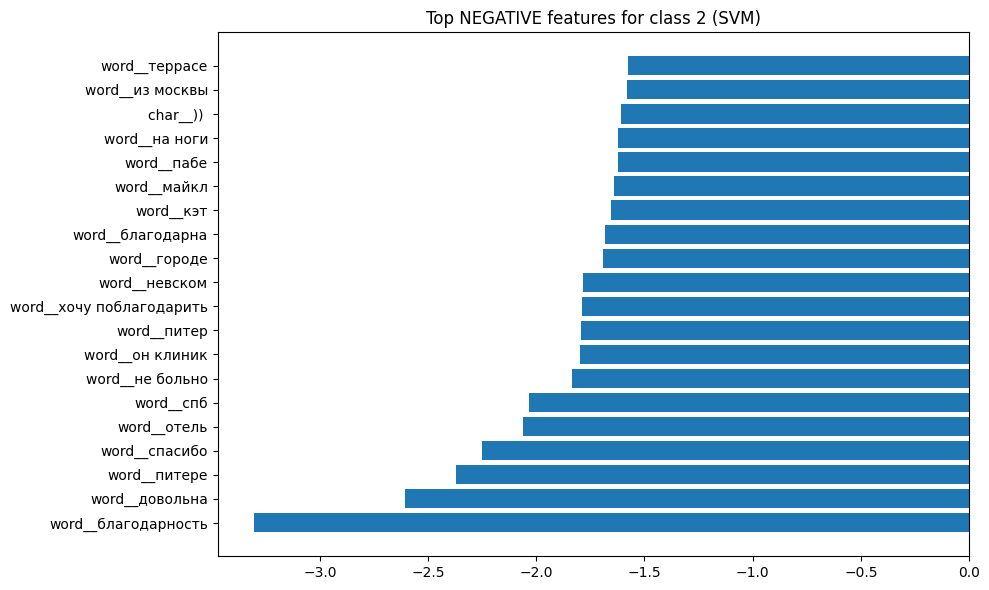

In [ ]:
plot_top_features(class_idx=2, topn=20)

Модель очень уверенно распознаёт негатив по:
*  прямым негативным формулировкам ("не рекомендую", "не советую"),
*  эмоциональному паттерну (множественные "!"),
грубой или агрессивной лексике,
*  описанию плохого качества ("грязно", "хамство", "плохое отношение"),
*  сарказму и контекстным выражениям ("единственный плюс").

Негативные признаки более разнообразны, чем позитивные.

Для классических методов машинного обучения наиболее эффективным решением оказалась комбинация: *Word TF-IDF + Char TF-IDF + Linear SVM*.
Она дала лучший баланс качества, устойчивости и интерпретируемости, достигая предположительно верхней границы для классического ML в рамках задачи определения тональности текстов.
Дальнейшее существенное повышение качества возможно в первую очередь при переходе к моделям на базе эмбеддингов ruBERT, но в рамках классического ML полученный результат (~0.77) является сильным и обоснованным потолком.